# SHAILESH GOWTHAM - 24BAD108

# Scenario - 1

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [17]:
file_path = '/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv'
df = pd.read_csv(file_path)

In [18]:
print("--- Data Inspection ---")
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
X = df[features]
y = df['diagnosis']

print(X.head())
print(f"\nMissing values:\n{X.isnull().sum()}\n")

--- Data Inspection ---
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean
0        17.99         10.38          122.80     1001.0          0.11840
1        20.57         17.77          132.90     1326.0          0.08474
2        19.69         21.25          130.00     1203.0          0.10960
3        11.42         20.38           77.58      386.1          0.14250
4        20.29         14.34          135.10     1297.0          0.10030

Missing values:
radius_mean        0
texture_mean       0
perimeter_mean     0
area_mean          0
smoothness_mean    0
dtype: int64



In [19]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [21]:
print("--- Analyzing Model Sensitivity to K ---")
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    accuracies.append(acc)
    if k % 5 == 0 or k == 1:
        print(f"K = {k:2} | Accuracy = {acc:.4f}")

best_k = 5 
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

--- Analyzing Model Sensitivity to K ---
K =  1 | Accuracy = 0.9298
K =  5 | Accuracy = 0.9298
K = 10 | Accuracy = 0.9561
K = 15 | Accuracy = 0.9561
K = 20 | Accuracy = 0.9649


KNeighborsClassifier()

In [22]:
y_pred = knn_final.predict(X_test)

print(f"\n--- Final KNN Performance (K={best_k}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}\n")


--- Final KNN Performance (K=5) ---
Accuracy:  0.9298
Precision: 0.9070
Recall:    0.9070
F1 Score:  0.9070



In [23]:
misclassified_idx = np.where(y_test != y_pred)[0]
print(f"--- Misclassified Cases (Total: {len(misclassified_idx)}) ---")
for idx in misclassified_idx[:3]: # Show first 3
    print(f"Actual: {'Malignant' if y_test[idx]==1 else 'Benign'} | Predicted: {'Malignant' if y_pred[idx]==1 else 'Benign'}")

--- Misclassified Cases (Total: 8) ---
Actual: Malignant | Predicted: Benign
Actual: Malignant | Predicted: Benign
Actual: Benign | Predicted: Malignant


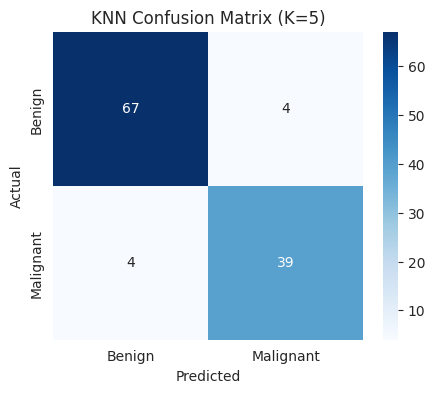

In [24]:
sns.set_style("whitegrid")

# 1. Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

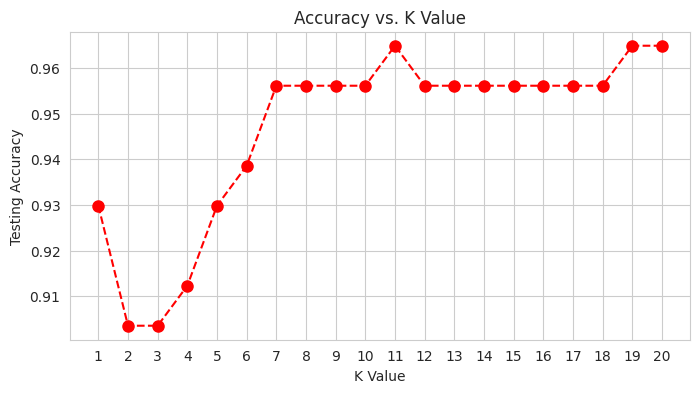

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='red', markersize=8)
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Testing Accuracy')
plt.xticks(k_values)
plt.show()

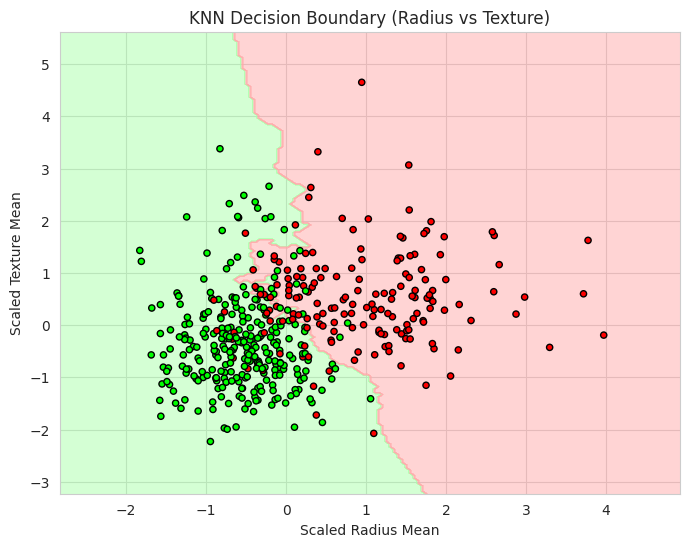

In [27]:
X_2d = X_train[:, :2] 
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_2d, y_train)

plt.figure(figsize=(8, 6))
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])
cmap_bold = ListedColormap(['#00FF00', '#FF0000'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=20)
plt.title("KNN Decision Boundary (Radius vs Texture)")
plt.xlabel("Scaled Radius Mean")
plt.ylabel("Scaled Texture Mean")
plt.show()

# Scenario 2

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [29]:
file_path = '/kaggle/input/datasets/ninzaami/loan-predication/train_u6lujuX_CVtuZ9i (1).csv'
df = pd.read_csv(file_path)

In [30]:
features = ['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Education', 'Property_Area']
X_raw = df[features].copy()
y_raw = df['Loan_Status']

In [31]:
X_raw['LoanAmount'] = X_raw['LoanAmount'].fillna(X_raw['LoanAmount'].median())
X_raw['Credit_History'] = X_raw['Credit_History'].fillna(X_raw['Credit_History'].mode()[0])

X_raw['Education'] = X_raw['Education'].map({'Graduate': 1, 'Not Graduate': 0})
X = pd.get_dummies(X_raw, columns=['Property_Area'], drop_first=True)

y = y_raw.map({'Y': 1, 'N': 0})

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [33]:
dt_deep = DecisionTreeClassifier(random_state=42)
dt_deep.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [34]:
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [35]:
y_pred_shallow = dt_shallow.predict(X_test)

print("--- Pruned Decision Tree Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_shallow):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_shallow):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_shallow):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_shallow):.4f}\n")

--- Pruned Decision Tree Performance ---
Accuracy:  0.7403
Precision: 0.7206
Recall:    0.9800
F1 Score:  0.8305



In [36]:
print("--- Overfitting Detection (Shallow vs Deep) ---")
train_acc_deep = accuracy_score(y_train, dt_deep.predict(X_train))
test_acc_deep = accuracy_score(y_test, dt_deep.predict(X_test))

train_acc_shallow = accuracy_score(y_train, dt_shallow.predict(X_train))
test_acc_shallow = accuracy_score(y_test, dt_shallow.predict(X_test))

print(f"Deep Tree (Unpruned) - Train Acc: {train_acc_deep:.4f} | Test Acc: {test_acc_deep:.4f}")
print(f"Shallow Tree (Pruned) - Train Acc: {train_acc_shallow:.4f} | Test Acc: {test_acc_shallow:.4f}")
print("Observation: The deep tree has near 100% training accuracy but lower testing accuracy, indicating overfitting. The shallow tree generalizes better.\n")

--- Overfitting Detection (Shallow vs Deep) ---
Deep Tree (Unpruned) - Train Acc: 1.0000 | Test Acc: 0.6818
Shallow Tree (Pruned) - Train Acc: 0.8261 | Test Acc: 0.7403
Observation: The deep tree has near 100% training accuracy but lower testing accuracy, indicating overfitting. The shallow tree generalizes better.



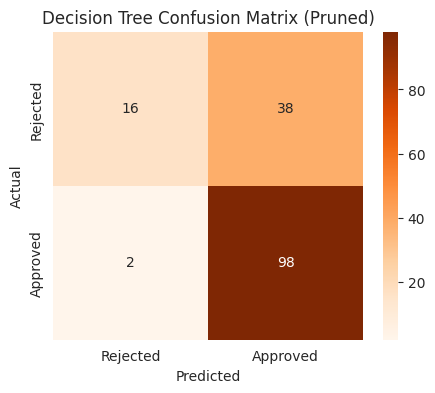

In [37]:
sns.set_style("whitegrid")

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_shallow)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Decision Tree Confusion Matrix (Pruned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

/tmp/ipykernel_55/1352390111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


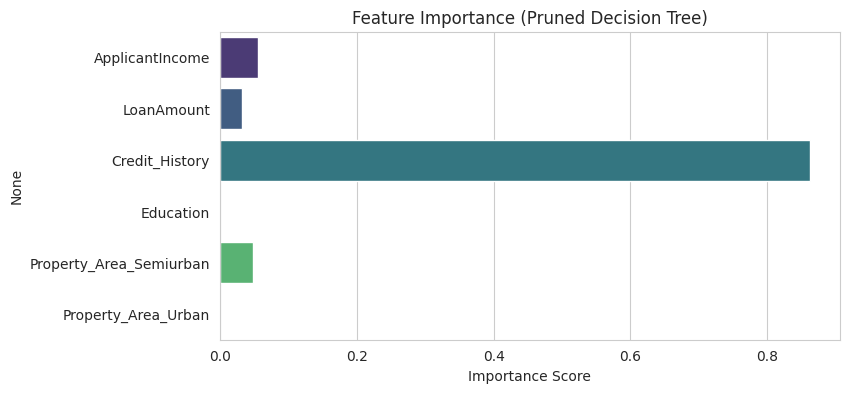

In [38]:
plt.figure(figsize=(8, 4))
importances = dt_shallow.feature_importances_
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Feature Importance (Pruned Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

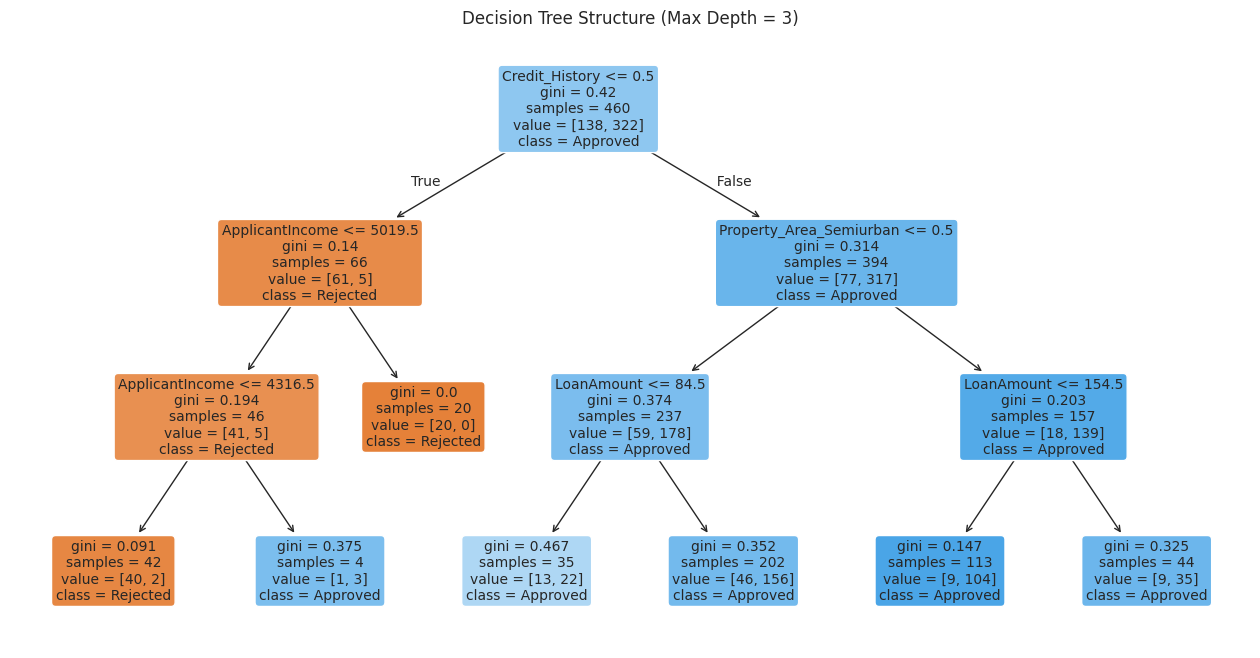

In [39]:
plt.figure(figsize=(16, 8))
plot_tree(dt_shallow, 
          feature_names=X.columns.tolist(),  
          class_names=['Rejected', 'Approved'],
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Structure (Max Depth = 3)")
plt.show()